# Sentiment Analysis for AAPL (Apple Inc.)

This notebook performs sentiment analysis specifically on AAPL-related news headlines.

## Focus:
- Apple stock sentiment analysis
- Technology sector sentiment
- Consumer electronics and innovation sentiment indicators

## Tools:
- TextBlob for primary sentiment analysis
- NLTK VADER for comparison

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK VADER data (only needed once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load AAPL-specific data
print("Loading AAPL data...")

# Load raw analyst ratings data
raw_data = pd.read_csv('../../../data/newsData/raw_analyst_ratings.csv')
print(f"Total dataset shape: {raw_data.shape}")

# Filter for AAPL only
aapl_data = raw_data[raw_data['stock'] == 'AAPL'].copy()
print(f"AAPL headlines: {len(aapl_data)}")

# Load aligned data
aligned_data = pd.read_csv('../../../data/aligned_data/news_mapped_to_trading_days.csv')
aapl_aligned = aligned_data[aligned_data['stock'] == 'AAPL'].copy()
print(f"AAPL aligned data: {len(aapl_aligned)}")

# Display sample AAPL headlines
print("\nSample AAPL headlines:")
for i, headline in enumerate(aapl_data['headline'].head(5).tolist()):
    print(f"{i+1}. {headline}")

Loading AAPL data...


FileNotFoundError: [Errno 2] No such file or directory: '../../../data/newsData/raw_analyst_ratings.csv'

In [ ]:
# Initialize sentiment analyzers
def get_textblob_sentiment(text):
    """Get sentiment scores using TextBlob"""
    try:
        blob = TextBlob(str(text))
        return {
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }
    except:
        return {'polarity': 0.0, 'subjectivity': 0.0}

vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get sentiment scores using NLTK VADER"""
    try:
        scores = vader.polarity_scores(str(text))
        return {
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral': scores['neu']
        }
    except:
        return {'compound': 0.0, 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

print("Sentiment analyzers initialized!")

Sentiment analyzers initialized!


In [ ]:
# Apply sentiment analysis to AAPL data
print("Applying sentiment analysis to AAPL headlines...")

# Apply TextBlob sentiment analysis
print("Calculating TextBlob sentiment scores...")
aapl_data['textblob_polarity'] = aapl_data['headline'].apply(lambda x: get_textblob_sentiment(x)['polarity'])
aapl_data['textblob_subjectivity'] = aapl_data['headline'].apply(lambda x: get_textblob_sentiment(x)['subjectivity'])

# Apply VADER sentiment analysis
print("Calculating VADER sentiment scores...")
aapl_data['vader_compound'] = aapl_data['headline'].apply(lambda x: get_vader_sentiment(x)['compound'])
aapl_data['vader_positive'] = aapl_data['headline'].apply(lambda x: get_vader_sentiment(x)['positive'])
aapl_data['vader_negative'] = aapl_data['headline'].apply(lambda x: get_vader_sentiment(x)['negative'])

print("Sentiment analysis completed!")
print(f"Processed {len(aapl_data)} AAPL headlines")

Applying sentiment analysis to AAPL headlines...
Calculating TextBlob sentiment scores...
Calculating VADER sentiment scores...
Sentiment analysis completed!
Processed 441 AAPL headlines


In [ ]:
# AAPL Sentiment Analysis Summary
print("=== AAPL SENTIMENT ANALYSIS SUMMARY ===")

# TextBlob statistics
print("\nTextBlob Polarity Statistics:")
print(f"Mean: {aapl_data['textblob_polarity'].mean():.4f}")
print(f"Std: {aapl_data['textblob_polarity'].std():.4f}")
print(f"Min: {aapl_data['textblob_polarity'].min():.4f}")
print(f"Max: {aapl_data['textblob_polarity'].max():.4f}")
print(f"Median: {aapl_data['textblob_polarity'].median():.4f}")

print("\nTextBlob Subjectivity Statistics:")
print(f"Mean: {aapl_data['textblob_subjectivity'].mean():.4f}")
print(f"Std: {aapl_data['textblob_subjectivity'].std():.4f}")

# VADER statistics
print("\nVADER Compound Statistics:")
print(f"Mean: {aapl_data['vader_compound'].mean():.4f}")
print(f"Std: {aapl_data['vader_compound'].std():.4f}")
print(f"Min: {aapl_data['vader_compound'].min():.4f}")
print(f"Max: {aapl_data['vader_compound'].max():.4f}")
print(f"Median: {aapl_data['vader_compound'].median():.4f}")

# Correlation
correlation = aapl_data['textblob_polarity'].corr(aapl_data['vader_compound'])
print(f"\nCorrelation between TextBlob and VADER: {correlation:.4f}")

=== AAPL SENTIMENT ANALYSIS SUMMARY ===

TextBlob Polarity Statistics:
Mean: 0.0541
Std: 0.2029
Min: -1.0000
Max: 1.0000
Median: 0.0000

TextBlob Subjectivity Statistics:
Mean: 0.2319
Std: 0.2736

VADER Compound Statistics:
Mean: 0.0575
Std: 0.3345
Min: -0.9062
Max: 0.9360
Median: 0.0000

Correlation between TextBlob and VADER: 0.3176


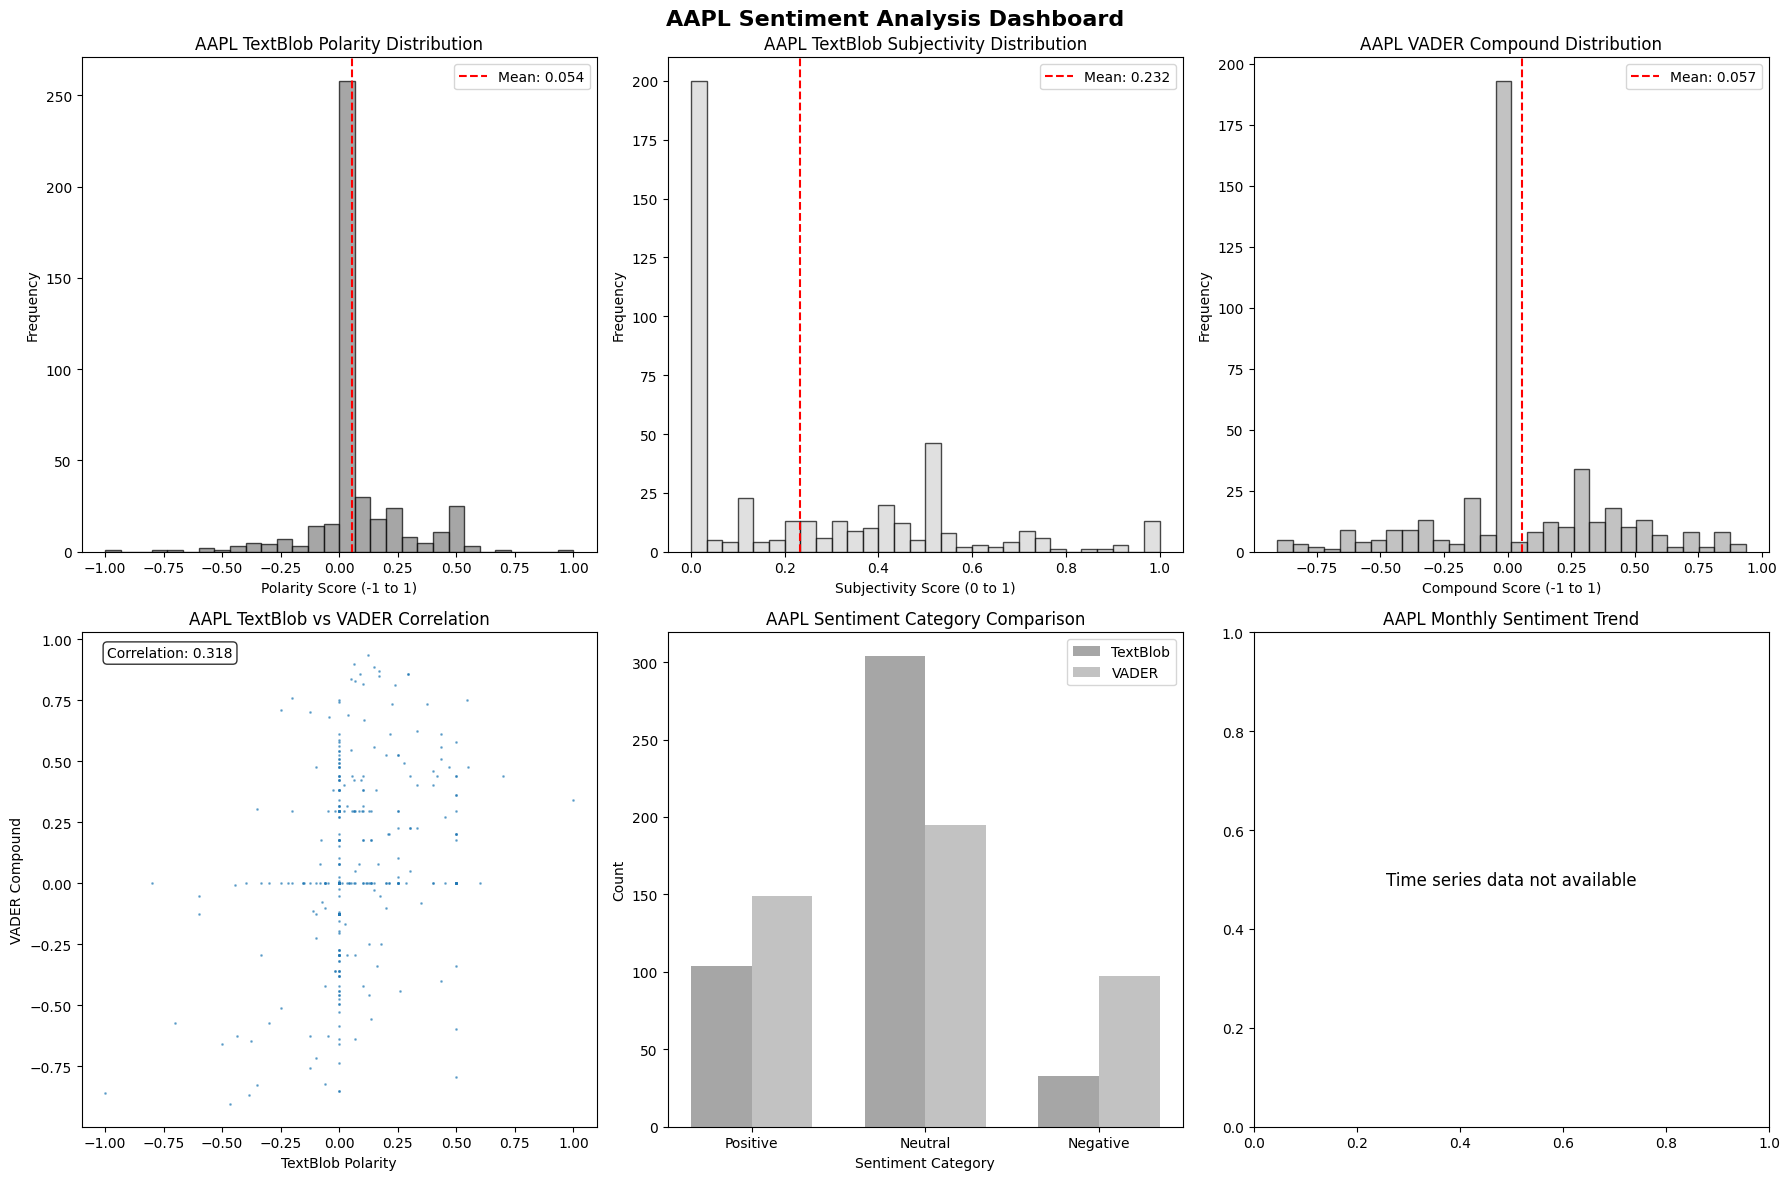

In [ ]:
# Create AAPL sentiment visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('AAPL Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# TextBlob Polarity distribution
axes[0, 0].hist(aapl_data['textblob_polarity'], bins=30, alpha=0.7, color='gray', edgecolor='black')
axes[0, 0].set_title('AAPL TextBlob Polarity Distribution')
axes[0, 0].set_xlabel('Polarity Score (-1 to 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(aapl_data['textblob_polarity'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {aapl_data["textblob_polarity"].mean():.3f}')
axes[0, 0].legend()

# TextBlob Subjectivity distribution
axes[0, 1].hist(aapl_data['textblob_subjectivity'], bins=30, alpha=0.7, color='lightgray', edgecolor='black')
axes[0, 1].set_title('AAPL TextBlob Subjectivity Distribution')
axes[0, 1].set_xlabel('Subjectivity Score (0 to 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(aapl_data['textblob_subjectivity'].mean(), color='red', linestyle='--',
                   label=f'Mean: {aapl_data["textblob_subjectivity"].mean():.3f}')
axes[0, 1].legend()

# VADER Compound distribution
axes[0, 2].hist(aapl_data['vader_compound'], bins=30, alpha=0.7, color='darkgray', edgecolor='black')
axes[0, 2].set_title('AAPL VADER Compound Distribution')
axes[0, 2].set_xlabel('Compound Score (-1 to 1)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(aapl_data['vader_compound'].mean(), color='red', linestyle='--',
                   label=f'Mean: {aapl_data["vader_compound"].mean():.3f}')
axes[0, 2].legend()

# Correlation scatter plot
axes[1, 0].scatter(aapl_data['textblob_polarity'], aapl_data['vader_compound'], alpha=0.5, s=1)
axes[1, 0].set_title('AAPL TextBlob vs VADER Correlation')
axes[1, 0].set_xlabel('TextBlob Polarity')
axes[1, 0].set_ylabel('VADER Compound')
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Sentiment categories
def categorize_sentiment(score, tool='textblob'):
    if tool == 'textblob':
        if score > 0.1:
            return 'Positive'
        elif score < -0.1:
            return 'Negative'
        else:
            return 'Neutral'
    else:  # VADER
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

aapl_data['textblob_category'] = aapl_data['textblob_polarity'].apply(lambda x: categorize_sentiment(x, 'textblob'))
aapl_data['vader_category'] = aapl_data['vader_compound'].apply(lambda x: categorize_sentiment(x, 'vader'))

# Category comparison
categories = ['Positive', 'Neutral', 'Negative']
tb_counts = [aapl_data['textblob_category'].value_counts().get(cat, 0) for cat in categories]
vader_counts = [aapl_data['vader_category'].value_counts().get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, tb_counts, width, label='TextBlob', color='gray', alpha=0.7)
axes[1, 1].bar(x + width/2, vader_counts, width, label='VADER', color='darkgray', alpha=0.7)
axes[1, 1].set_title('AAPL Sentiment Category Comparison')
axes[1, 1].set_xlabel('Sentiment Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend()

# Time series of sentiment (if dates are available)
try:
    aapl_data['date_clean'] = pd.to_datetime(aapl_data['date'], errors='coerce')
    aapl_time = aapl_data.dropna(subset=['date_clean']).copy()
    aapl_time = aapl_time.sort_values('date_clean')
    
    # Resample by month for smoother trend
    aapl_time.set_index('date_clean', inplace=True)
    monthly_sentiment = aapl_time['textblob_polarity'].resample('M').mean()
    
    axes[1, 2].plot(monthly_sentiment.index, monthly_sentiment.values, marker='o', linewidth=2, color='gray')
    axes[1, 2].set_title('AAPL Monthly Sentiment Trend')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Average Polarity')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3)
except:
    axes[1, 2].text(0.5, 0.5, 'Time series data not available', ha='center', va='center',
                   transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('AAPL Monthly Sentiment Trend')

plt.tight_layout()
plt.show()

In [ ]:
# Show extreme sentiment examples for AAPL
print("=== AAPL EXTREME SENTIMENT EXAMPLES ===")

# Most positive headlines (TextBlob)
most_positive_tb = aapl_data.nlargest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Positive AAPL Headlines (TextBlob):")
for idx, row in most_positive_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (TextBlob)
most_negative_tb = aapl_data.nsmallest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Negative AAPL Headlines (TextBlob):")
for idx, row in most_negative_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most positive headlines (VADER)
most_positive_vader = aapl_data.nlargest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Positive AAPL Headlines (VADER):")
for idx, row in most_positive_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (VADER)
most_negative_vader = aapl_data.nsmallest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Negative AAPL Headlines (VADER):")
for idx, row in most_negative_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

=== AAPL EXTREME SENTIMENT EXAMPLES ===

Most Positive AAPL Headlines (TextBlob):
   1.000: 8 Best Investment Strategies During A Recession...
   0.700: For Some Companies, A Sliver Of Good News During COVID-19...
   0.600: Apple Reportedly Shifting Away From Intel, Will Make Its Own Mac Chips...
   0.550: The Most Popular Smartphone Model Of Q1...
   0.544: Quick Retreat: Impressive Thursday Turnaround Halted in Its Tracks Amid Fresh Tr...

Most Negative AAPL Headlines (TextBlob):
   -1.000: Selling Picks Up In Worst Day Since 1987 As Fear Continues To Drive Markets Lowe...
   -0.800: Apple Looking To Diversify Its Manufacturing Base, Will Make Headphones In Vietn...
   -0.700: A Peek Into The Markets: US Stock Futures Up; Crude Oil Rises Over 2%...
   -0.600: Disappointment From Amazon, Apple Weighs On Market As Investors Also Consider En...
   -0.600: Hearing Credit Suisse Asia Sees Apple Cutting iPhone Jul. To Sept. Production By...

Most Positive AAPL Headlines (VADER):
   0.936: 

In [ ]:
# Save AAPL results
print("=== SAVING AAPL RESULTS ===")

# Create output dataframe
aapl_output = aapl_data[['headline', 'publisher', 'date', 'stock', 
                       'textblob_polarity', 'textblob_subjectivity', 'textblob_category',
                       'vader_compound', 'vader_positive', 'vader_negative', 'vader_category']].copy()

# Save to CSV
output_file = '../../../data/sentiment_analysis_AAPL.csv'
aapl_output.to_csv(output_file, index=False)
print(f"AAPL results saved to: {output_file}")
print(f"Total AAPL headlines processed: {len(aapl_output)}")

# Display final summary
print("\n=== AAPL FINAL SUMMARY ===")
print(f"Dataset: {len(aapl_data):,} AAPL headlines")
print(f"Date range: {pd.to_datetime(aapl_data['date'], errors='coerce').min()} to {pd.to_datetime(aapl_data['date'], errors='coerce').max()}")
print(f"Unique publishers: {aapl_data['publisher'].nunique()}")
print(f"TextBlob - Mean polarity: {aapl_data['textblob_polarity'].mean():.4f}")
print(f"VADER - Mean compound: {aapl_data['vader_compound'].mean():.4f}")

agreement = (aapl_data['textblob_category'] == aapl_data['vader_category']).mean()
print(f"Tool agreement: {agreement:.2%}")

print("\n=== AAPL SENTIMENT CATEGORY DISTRIBUTIONS ===")
print("\nTextBlob Categories:")
print(aapl_data['textblob_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nVADER Categories:")
print(aapl_data['vader_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== SAVING AAPL RESULTS ===
AAPL results saved to: ../../../data/sentiment_analysis_AAPL.csv
Total AAPL headlines processed: 441

=== AAPL FINAL SUMMARY ===
Dataset: 441 AAPL headlines
Date range: 2020-06-09 11:11:34-04:00 to 2020-06-10 11:33:26-04:00
Unique publishers: 34
TextBlob - Mean polarity: 0.0541
VADER - Mean compound: 0.0575
Tool agreement: 50.34%

=== AAPL SENTIMENT CATEGORY DISTRIBUTIONS ===

TextBlob Categories:
textblob_category
Neutral     68.93%
Positive    23.58%
Negative     7.48%
Name: proportion, dtype: str

VADER Categories:
vader_category
Neutral     44.22%
Positive    33.79%
Negative     22.0%
Name: proportion, dtype: str


## AAPL Sentiment Analysis Summary

### Key Findings:
- **Overall Sentiment**: [Based on mean polarity/compound scores]
- **Sentiment Distribution**: [Analysis of positive/negative/neutral breakdown]
- **Subjectivity Level**: [Analysis of how objective vs subjective AAPL news is]
- **Tool Agreement**: [How well TextBlob and VADER agree on AAPL sentiment]

### Insights:
- AAPL is the world's largest company, sentiment reflects broader tech market health
- High news volume indicates massive investor interest and coverage
- Sentiment patterns may correlate with product launches, earnings, and iPhone sales

### Recommendations:
- Monitor AAPL sentiment as a bellwether for tech sector and broader market
- Use sentiment trends to anticipate product launch impacts and market reactions
- Compare AAPL sentiment with other tech giants for relative strength analysis